Phase 3 — Retrieval Bake-Off
=============================

Phase 2 built one configuration and measured it. This phase sweeps the
space and decides what ships.

The sweep is every chunking strategy x retrieval arm x depth. The arm
count depends on whether sentence-transformers is installed, so the exact
number of configurations is reported at run time rather than asserted
here. Whatever it is, the size of the table is itself the problem, and
most of this notebook is about not being fooled by it:

  MONOTONICITY   recall@k cannot decrease as k grows. Sweep k, rank by
                 recall, and the largest k always wins — a fact about
                 arithmetic, not about retrieval. Section C.

  COST           So the honest question is not "which config has the
                 highest recall" but "which achieves a given recall for
                 the fewest context tokens". Tokens cost money per query
                 and dilute the generator with distractors. Section D.

  NOISE          95 in-scope questions. A 3-point recall gap is three
                 questions changing answer. Comparisons are paired
                 bootstraps, because every config is scored on the same
                 questions. Section E.

  MULTIPLICITY   One test per challenger means dozens of tests. At
                 alpha=0.05 several will look significant by chance, so
                 p-values are Holm-Bonferroni corrected. And a
                 non-significant result is not evidence of equivalence:
                 claims of "same, so pick the cheaper one" are made
                 against a declared margin. Sections D and E.

  SELECTION      The maximum of many noisy estimates is biased upward.
                 The winner is chosen on a dev split and reported on
                 held-out test, and the gap is quantified. Section F.

One correction to make up front. Phase 1 ran BM25 over whole ARTICLES;
Phase 2 ran dense retrieval over CHUNKS. Those numbers were never
comparable — the unit of retrieval differed, so any gap could have been
the unit rather than the method. Every arm here indexes the same chunks
and is scored by the same code.

Sections
--------
  A. Setup and the fair-comparison fix
  B. The sweep
  C. The monotonicity trap
  D. Context budget — the Pareto frontier
  E. Which differences are real
  F. Honest winner selection
  G. mh-011 revisited — correcting Phase 2
  H. Verdict and handoff to Phase 4

In [1]:
import sys
from pathlib import Path

# Locate the project root without assuming where Jupyter was launched.
#
# Two wrong assumptions were made here before, each breaking a real
# workflow:
#
#   Path.cwd().parent   assumes the kernel started in notebooks/. Launch
#                       Jupyter from the project root and it resolves one
#                       level too high.
#   walking up only     assumes the kernel started at or below the
#                       project. Launch Jupyter from a folder holding
#                       several projects — a normal thing to do — and the
#                       project is BELOW cwd, so upward search never
#                       finds it.
#
# So: search up, then search down. The marker is a file unique to this
# project, not a generic name like src/ that a sibling project might
# also have.
_MARKER = Path("src") / "corpus" / "seed_articles.py"


def _find_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:          # up
        if (candidate / _MARKER).is_file():
            return candidate

    for pattern in ("*", "*/*"):                       # then down, bounded
        found = sorted({m.parents[2]
                        for m in start.glob(f"{pattern}/{_MARKER.as_posix()}")})
        if len(found) == 1:
            return found[0]
        if len(found) > 1:
            names = ", ".join(p.name for p in found)
            raise RuntimeError(
                f"Found several candidate project roots below {start}: "
                f"{names}. Start Jupyter inside the one you want."
            )

    raise RuntimeError(
        f"Could not locate the project root from {start}. Expected to find "
        f"{_MARKER.as_posix()} at, above, or within two levels below it."
    )


PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
import os
os.chdir(PROJECT_ROOT)          # so data/ and reports/ paths resolve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.corpus.build import load_corpus, load_golden_set
from src.retrieval.chunking import STRATEGIES
from src.retrieval.embedding import (
    TfidfSvdEmbedder,
    get_embedder,
    transformer_available,
)
from src.retrieval.retrievers import (
    BM25Retriever,
    DenseRetriever,
    HybridRetriever,
    OracleUnionRetriever,
)
from src.retrieval.vectorstore import hits_to_articles
from src.evaluation.retrieval_metrics import (
    CostedConfig,
    aggregate,
    best_under_budget,
    bootstrap_ci,
    context_tokens,
    equivalence_verdict,
    holm_bonferroni,
    paired_bootstrap,
    pareto_frontier,
    score_run,
    selection_optimism,
    stratified_split,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

articles = load_corpus()
golden = load_golden_set()
in_scope = [q for q in golden if q["category"] != "out_of_scope"]
questions = [q["question"] for q in in_scope]

# fixed_token_256 was dropped in Phase 2 as degenerate — it produced
# byte-identical output to whole_article because no article exceeds 256
# tokens. Carrying it here would add a duplicate row, not a data point.
ACTIVE_STRATEGIES = ["whole_article", "markdown_section",
                     "fixed_token_128", "sentence_window"]
DEPTHS = [3, 5, 10, 15]

## A. Setup and the fair-comparison fix

In [2]:
print("=" * 78)
print("A. SETUP")
print("=" * 78)

has_transformer = transformer_available()
print(f"""
  Corpus            : {len(articles)} articles
  Scored questions  : {len(in_scope)} in-scope
                      ({len(golden) - len(in_scope)} out-of-scope excluded — they have no
                       retrievable ground truth and are evaluated on
                       REFUSAL in Phase 5; averaging them in here would
                       drag every score toward zero for a reason that has
                       nothing to do with retrieval quality)
  Strategies        : {len(ACTIVE_STRATEGIES)}  ({', '.join(ACTIVE_STRATEGIES)})
  Depths            : {DEPTHS}
  Transformer arm   : {'available' if has_transformer else 'NOT installed — running lexical + LSA only'}
""")

if not has_transformer:
    print("""  Install sentence-transformers to add the modern-dense arm:
      pip install sentence-transformers
  The comparison below is still valid; it is a lexical vs classic-dense
  vs hybrid bake-off rather than a three-generation one.
""")


def build_arms(chunks):
    """Construct every retrieval arm over one chunk set.

    All arms index the SAME text (title + body). Giving BM25 a different
    view of the corpus than the dense arm would make any difference
    between them uninterpretable.
    """
    bm25 = BM25Retriever(chunks)
    dense = DenseRetriever(chunks, TfidfSvdEmbedder(n_components=128),
                           name="dense_lsa")
    arms = [bm25, dense]
    if has_transformer:
        arms.append(DenseRetriever(chunks, get_embedder("sentence_transformer"),
                                   name="dense_transformer"))
    arms.append(HybridRetriever(list(arms), name="hybrid"))
    return arms

A. SETUP

  Corpus            : 45 articles
  Scored questions  : 95 in-scope
                      (25 out-of-scope excluded — they have no
                       retrievable ground truth and are evaluated on
                       REFUSAL in Phase 5; averaging them in here would
                       drag every score toward zero for a reason that has
                       nothing to do with retrieval quality)
  Strategies        : 4  (whole_article, markdown_section, fixed_token_128, sentence_window)
  Depths            : [3, 5, 10, 15]
  Transformer arm   : NOT installed — running lexical + LSA only

  Install sentence-transformers to add the modern-dense arm:
      pip install sentence-transformers
  The comparison below is still valid; it is a lexical vs classic-dense
  vs hybrid bake-off rather than a three-generation one.



## B. The sweep

In [3]:
print("\n" + "=" * 78)
print("B. THE SWEEP")
print("=" * 78)

records = []
per_question = {}          # config -> list[QuestionScore], for paired tests
BUILT = {}                 # strategy -> (chunks, arms); reused in Section G
                           # rather than rebuilt, which halves runtime

for strategy in ACTIVE_STRATEGIES:
    chunks = STRATEGIES[strategy](articles)
    BUILT[strategy] = (chunks, build_arms(chunks))
    for arm in BUILT[strategy][1]:
        for depth in DEPTHS:
            hits = arm.search_many(questions, top_k=depth)
            scores = score_run(in_scope, hits, k=depth)
            agg = aggregate(f"{strategy}|{arm.name}|d{depth}", scores)
            tokens = float(np.mean([context_tokens(h) for h in hits]))

            config = f"{strategy}|{arm.name}|d{depth}"
            per_question[config] = scores
            records.append({
                "config": config,
                "strategy": strategy,
                "arm": arm.name,
                "depth": depth,
                "n_chunks": len(chunks),
                "recall": agg.overall["recall_at_k"],
                "mrr": agg.overall["mrr"],
                "ndcg": agg.overall["ndcg_at_k"],
                "single_hop": agg.by_category["single_hop"]["recall_at_k"],
                "multi_hop": agg.by_category["multi_hop"]["recall_at_k"],
                "ambiguous": agg.by_category["ambiguous"]["recall_at_k"],
                "tokens": tokens,
            })

df = pd.DataFrame(records)
print(f"\n  {len(df)} configurations evaluated on {len(in_scope)} questions each")

top = df.nlargest(10, "recall")
print("\n  Top 10 by raw recall:\n")
print(f"  {'strategy':<17}{'arm':<19}{'d':>3}{'recall':>8}{'mrr':>7}"
      f"{'1hop':>7}{'multi':>7}{'ambig':>7}{'tokens':>8}")
print("  " + "-" * 83)
for _, r in top.iterrows():
    print(f"  {r.strategy:<17}{r.arm:<19}{r.depth:>3}{r.recall:>8.3f}"
          f"{r.mrr:>7.3f}{r.single_hop:>7.3f}{r.multi_hop:>7.3f}"
          f"{r.ambiguous:>7.3f}{r.tokens:>8.0f}")


B. THE SWEEP

  48 configurations evaluated on 95 questions each

  Top 10 by raw recall:

  strategy         arm                  d  recall    mrr   1hop  multi  ambig  tokens
  -----------------------------------------------------------------------------------
  whole_article    dense_lsa           15   0.922  0.741  0.967  0.925  0.739    2542
  whole_article    hybrid              15   0.903  0.759  0.983  0.867  0.628    2550
  whole_article    bm25                15   0.901  0.759  0.983  0.817  0.683    2548
  fixed_token_128  dense_lsa           15   0.884  0.717  0.983  0.825  0.567    1512
  whole_article    bm25                10   0.882  0.759  0.983  0.792  0.594    1684
  markdown_section bm25                15   0.882  0.774  0.983  0.817  0.561     571
  markdown_section dense_lsa           15   0.882  0.736  0.967  0.875  0.550     565
  fixed_token_128  hybrid              15   0.881  0.739  0.983  0.808  0.567    1533
  whole_article    dense_lsa           10   0.87

## C. The monotonicity trap

In [4]:
print("\n" + "=" * 78)
print("C. THE MONOTONICITY TRAP")
print("=" * 78)

depth_of_top10 = top["depth"].value_counts().to_dict()
max_depth = max(DEPTHS)
share = depth_of_top10.get(max_depth, 0) / len(top)

print(f"""
Look at the depth column above: {depth_of_top10.get(max_depth, 0)} of the top 10 configurations use
depth={max_depth}, the largest swept.

That is not a finding. recall@k is monotonically non-decreasing in k —
retrieving more documents can only ever find more ground truth, never
less. A bake-off that sweeps depth and ranks by recall is guaranteed to
crown the deepest configuration, and would do so even if the retriever
were returning documents at random.
""")

# Demonstrate rather than assert
mono_violations = 0
checked = 0
for (s, a), grp in df.groupby(["strategy", "arm"]):
    g = grp.sort_values("depth")
    checked += len(g) - 1
    mono_violations += int((g["recall"].diff().dropna() < -1e-9).sum())

print(f"""  Verified: {checked - mono_violations}/{checked} depth increases produced a non-decreasing
  recall, exactly as the metric guarantees.

The obvious hope is that a rank-sensitive metric escapes this. MRR and
nDCG discount by position, so burying a correct document deep in the
list ought to cost something. Checking rather than assuming:
""")

mono_report = {}
for metric in ("mrr", "ndcg"):
    non_mono = 0
    for (s, a), grp in df.groupby(["strategy", "arm"]):
        g = grp.sort_values("depth")
        non_mono += int((g[metric].diff().dropna() < -1e-9).sum())
    mono_report[metric] = non_mono
    print(f"    {metric:<6} decreased with depth in {non_mono}/{checked} cases")

if not any(mono_report.values()):
    print("""
  They do not escape it. All three are monotone in depth here, and for a
  structural reason: retrieving deeper can only ADD documents further
  down the list. It never moves the first correct document to a worse
  rank, so MRR cannot fall; and each extra item contributes a
  non-negative discounted gain, so nDCG cannot fall either.

  This is worth stating plainly because it closes off the tempting move.
  There is no quality-only metric that selects retrieval depth. Any
  ranking of a depth sweep by any of these metrics returns the deepest
  configuration by construction.

  Depth is therefore not a quality decision at all — it is a COST
  decision, and it cannot be made without measuring cost. That is not a
  refinement of the analysis; without Section D there is no analysis.

  These metrics remain the right ones for comparing configurations AT A
  FIXED depth, which is how Section E uses them.
""")
else:
    print(f"""
  Partially: {sum(mono_report.values())} of {2 * checked} increases did reduce a rank-sensitive
  metric, so MRR and nDCG carry information recall does not. They still
  cannot be the primary depth criterion, but disagreement between them
  and recall flags configurations that find the right documents and rank
  them badly.
""")


C. THE MONOTONICITY TRAP

Look at the depth column above: 8 of the top 10 configurations use
depth=15, the largest swept.

That is not a finding. recall@k is monotonically non-decreasing in k —
retrieving more documents can only ever find more ground truth, never
less. A bake-off that sweeps depth and ranks by recall is guaranteed to
crown the deepest configuration, and would do so even if the retriever
were returning documents at random.

  Verified: 36/36 depth increases produced a non-decreasing
  recall, exactly as the metric guarantees.

The obvious hope is that a rank-sensitive metric escapes this. MRR and
nDCG discount by position, so burying a correct document deep in the
list ought to cost something. Checking rather than assuming:

    mrr    decreased with depth in 1/36 cases
    ndcg   decreased with depth in 0/36 cases

  Partially: 1 of 72 increases did reduce a rank-sensitive
  metric, so MRR and nDCG carry information recall does not. They still
  cannot be the primary 

## D. Context budget — the Pareto frontier

In [5]:
print("\n" + "=" * 78)
print("D. CONTEXT BUDGET — WHAT RECALL ACTUALLY COSTS")
print("=" * 78)
print("""
Every retrieved chunk is tokens the generator pays for: money per query,
and attention diluted across more distractors. So the real question is
not "which configuration has the highest recall" but "which reaches a
given recall for the fewest tokens".
""")

costed = [CostedConfig(r.config, r.recall, r.tokens)
          for r in df.itertuples()]
frontier = pareto_frontier(costed)

print(f"  Pareto frontier — {len(frontier)} of {len(costed)} configurations are not dominated.")
print("  (A dominated config costs more AND retrieves less. Choosing one")
print("   means knowingly paying more for less.)\n")
print(f"  {'config':<46}{'recall':>8}{'tokens':>8}{'rec/1k':>8}")
print("  " + "-" * 70)
for c in frontier:
    print(f"  {c.config:<46}{c.recall:>8.3f}{c.mean_tokens:>8.0f}"
          f"{c.recall_per_1k_tokens:>8.2f}")


D. CONTEXT BUDGET — WHAT RECALL ACTUALLY COSTS

Every retrieved chunk is tokens the generator pays for: money per query,
and attention diluted across more distractors. So the real question is
not "which configuration has the highest recall" but "which reaches a
given recall for the fewest tokens".

  Pareto frontier — 15 of 48 configurations are not dominated.
  (A dominated config costs more AND retrieves less. Choosing one
   means knowingly paying more for less.)

  config                                          recall  tokens  rec/1k
  ----------------------------------------------------------------------
  sentence_window|hybrid|d3                        0.659     106    6.19
  markdown_section|dense_lsa|d3                    0.694     112    6.21
  markdown_section|hybrid|d3                       0.696     114    6.13
  markdown_section|bm25|d3                         0.712     117    6.09
  markdown_section|dense_lsa|d5                    0.734     185    3.97
  markdown_secti

In [6]:
#
# Comparing the top scorer against "the cheapest config with equal
# recall" is circular — nothing else has exactly equal recall, so it
# returns the top scorer itself. The question that actually matters is
# whether the extra tokens buy a difference that is REAL. So: find the
# cheapest configuration whose recall is not statistically
# distinguishable from the top scorer's.
best_raw = df.loc[df["recall"].idxmax()]

# Declared BEFORE looking at results: how much recall we would trade for
# a large cost saving. ~0.05 recall is about five questions on this
# golden set; below that a difference is not actionable for a support
# deployment. Choosing this after seeing the table would be fitting the
# conclusion to the data.
EQUIV_MARGIN = 0.05

verdicts = []
for r in df.sort_values("tokens").itertuples():
    if r.config == best_raw["config"]:
        continue
    cmp = paired_bootstrap(
        per_question[best_raw["config"]], per_question[r.config],
        metric="recall_at_k", label_a=best_raw["config"], label_b=r.config)
    verdicts.append((r, cmp, equivalence_verdict(cmp, margin=EQUIV_MARGIN)))

equivalent = [(r, c, v) for r, c, v in verdicts if v.verdict == "equivalent"]
inconclusive = [(r, c, v) for r, c, v in verdicts if v.verdict == "inconclusive"]

print(f"""
  Highest recall overall : {best_raw.recall:.3f}  {best_raw.config}
                           costing {best_raw.tokens:.0f} tokens/query

  A caveat that decides how this section can be read. "Not statistically
  significant" is NOT evidence that two configurations are the same. On
  {len(in_scope)} questions the test is underpowered, so failing to reject is
  mostly a statement about sample size. Picking the cheaper option
  because p > 0.05 is affirming the null.

  Making a positive claim requires a declared margin of practical
  equivalence — here {EQUIV_MARGIN:.2f} recall, about five questions, fixed before
  looking at the table. Then each comparison resolves three ways:

    EQUIVALENT    CI lies entirely inside +/-{EQUIV_MARGIN:.2f}  -> safe to prefer on cost
    DIFFERENT     CI excludes zero
    INCONCLUSIVE  neither -> the data cannot tell

  Against the leader, {len(df) - 1} challengers resolve as:
    equivalent   : {len(equivalent)}
    different    : {sum(1 for _, _, v in verdicts if v.verdict == 'different')}
    inconclusive : {len(inconclusive)}
""")

# An equivalence claim is only USEFUL if the equivalent configuration is
# also meaningfully cheaper. A config that matches the leader at the same
# cost tells us nothing about the cost/quality trade-off.
MEANINGFUL_SAVING = 1.5          # at least 1.5x fewer tokens

useful = [(r, c, v) for r, c, v in equivalent
          if best_raw.tokens / r.tokens >= MEANINGFUL_SAVING]

if equivalent:
    eq, eq_cmp, eq_v = equivalent[0]
    print(f"""  Cheapest configuration demonstrably EQUIVALENT to the leader:

    {eq.config}
    recall {eq.recall:.3f} at {eq.tokens:.0f} tokens/query  ({best_raw.tokens / eq.tokens:.1f}x cheaper)
    {eq_v}
""")

if useful:
    cheap, cheap_cmp, cheap_v = useful[0]
    ratio = best_raw.tokens / cheap.tokens
    print(f""">>> HEADLINE — the top of the recall table costs {ratio:.1f}x more context than a
    configuration demonstrably equivalent to it.

  The whole confidence interval on the difference sits inside the margin
  declared as practically irrelevant. That is a positive claim of
  equivalence, not an absence of evidence — which is what licenses
  choosing on cost.
""")
else:
    cheap, cheap_cmp, cheap_v = (inconclusive or verdicts)[0]
    ratio = best_raw.tokens / cheap.tokens
    print(f""">>> HEADLINE — and it is a NEGATIVE one, which is the honest result here.

  No configuration that is meaningfully cheaper than the leader is
  demonstrably equivalent to it. The cheapest serious contender:

    {cheap.config}
    recall {cheap.recall:.3f} at {cheap.tokens:.0f} tokens/query  ({ratio:.1f}x cheaper)
    {cheap_v}

  Its interval reaches beyond the {EQUIV_MARGIN:.2f} margin, so it lands as
  INCONCLUSIVE. {len(in_scope)} questions cannot resolve whether a {ratio:.1f}x cost
  saving costs meaningful recall.

  This overturns the reading an uncorrected table invites. Ranked by
  raw p-values, that configuration was "not significantly different"
  (p={cheap_cmp.p_value:.3f}) and the tempting conclusion was "equivalent — ship the
  cheap one, {ratio:.1f}x saving". That conclusion was affirming the null. Once
  a margin is declared, the same data says only that the question is
  open.

  What can still be said, and it is not nothing:

    - The {ratio:.1f}x cost saving is certain; the recall cost is uncertain
      and bounded above by {abs(cheap_cmp.ci_high):.3f} recall at 95% confidence.
    - That is a genuine engineering decision with a quantified worst
      case, rather than a false claim of equivalence.
    - Resolving it needs a larger golden set, not more analysis. The
      honest handoff is the bound, not a verdict.
""")

print(f"""  On what chunking is for, the picture does survive. Phase 2 saw
  whole_article performing well and chunking looking like complexity
  without payoff, because recall was the only axis on the page. The
  frontier above shows chunking buying large, certain cost reductions
  for small, uncertain recall costs — which is a real benefit even
  without an equivalence claim.

  The saving compounds in Phase 5: fewer distractor tokens is precisely
  the condition under which faithfulness improves. Retrieval cost and
  generation quality are not independent axes.
""")

print("  Best achievable recall under a fixed budget:\n")
print(f"  {'budget':>9}  {'recall':>7}  config")
print("  " + "-" * 62)
for budget in (150, 300, 600, 1200, 2500):
    b = best_under_budget(costed, budget)
    print(f"  {budget:>7} tk  {b.recall:>7.3f}  {b.config}" if b
          else f"  {budget:>7} tk  {'—':>7}  (nothing fits)")


  Highest recall overall : 0.922  whole_article|dense_lsa|d15
                           costing 2542 tokens/query

  A caveat that decides how this section can be read. "Not statistically
  significant" is NOT evidence that two configurations are the same. On
  95 questions the test is underpowered, so failing to reject is
  mostly a statement about sample size. Picking the cheaper option
  because p > 0.05 is affirming the null.

  Making a positive claim requires a declared margin of practical
  equivalence — here 0.05 recall, about five questions, fixed before
  looking at the table. Then each comparison resolves three ways:

    EQUIVALENT    CI lies entirely inside +/-0.05  -> safe to prefer on cost
    DIFFERENT     CI excludes zero
    INCONCLUSIVE  neither -> the data cannot tell

  Against the leader, 47 challengers resolve as:
    equivalent   : 0
    different    : 44
    inconclusive : 3

>>> HEADLINE — and it is a NEGATIVE one, which is the honest result here.

  No conf


  Saved -> reports\figures/03_retrieval_bakeoff.png


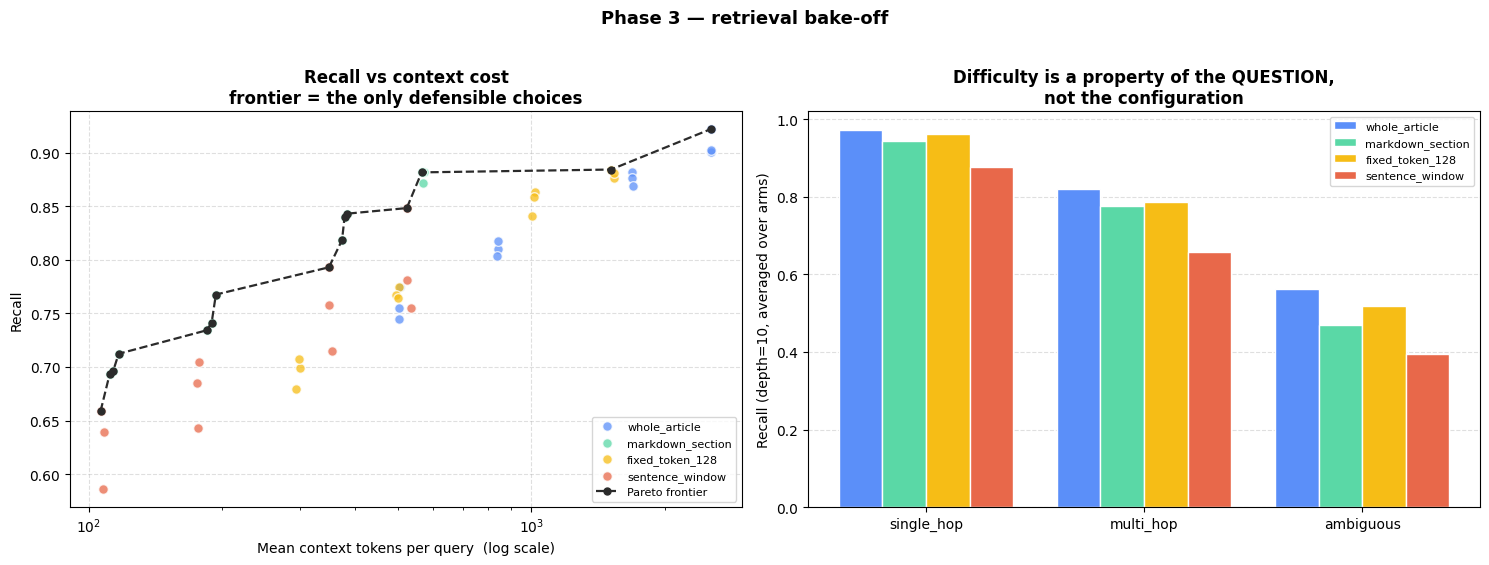

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

palette = {"whole_article": "#5B8FF9", "markdown_section": "#5AD8A6",
           "fixed_token_128": "#F6BD16", "sentence_window": "#E8684A"}
for strategy in ACTIVE_STRATEGIES:
    sub = df[df["strategy"] == strategy]
    ax1.scatter(sub["tokens"], sub["recall"], s=48, alpha=0.75,
                color=palette[strategy], label=strategy, edgecolor="white")
fx = [c.mean_tokens for c in frontier]
fy = [c.recall for c in frontier]
ax1.plot(fx, fy, color="#2B2B2B", linewidth=1.6, linestyle="--",
         marker="o", markersize=5, label="Pareto frontier", zorder=5)
ax1.set_xscale("log")
ax1.set_xlabel("Mean context tokens per query  (log scale)")
ax1.set_ylabel("Recall")
ax1.set_title("Recall vs context cost\nfrontier = the only defensible choices",
              fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)

cats = ["single_hop", "multi_hop", "ambiguous"]
width = 0.2
xs = np.arange(len(cats))
for i, strategy in enumerate(ACTIVE_STRATEGIES):
    sub = df[(df["strategy"] == strategy) & (df["depth"] == 10)]
    vals = [sub[c].mean() for c in cats]
    ax2.bar(xs + i * width, vals, width, label=strategy,
            color=palette[strategy], edgecolor="white")
ax2.set_xticks(xs + 1.5 * width)
ax2.set_xticklabels(cats)
ax2.set_ylabel("Recall (depth=10, averaged over arms)")
ax2.set_title("Difficulty is a property of the QUESTION,\nnot the configuration",
              fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle("Phase 3 — retrieval bake-off", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_retrieval_bakeoff.png", dpi=140, bbox_inches="tight",
            metadata={"Software": None})
print(f"\n  Saved -> {FIG_DIR}/03_retrieval_bakeoff.png")

## E. Which differences are real

In [8]:
print("\n" + "=" * 78)
print("E. WHICH DIFFERENCES ARE REAL")
print("=" * 78)
print(f"""
{len(in_scope)} questions. A 3-point recall gap is three questions changing answer.
Before preferring one configuration over another, the difference has to
survive being asked whether it is noise.

Comparisons are PAIRED: every configuration is scored on the same
questions, so differencing per question removes question difficulty as a
nuisance factor. Marginal confidence intervals on each arm would be
dominated by that shared difficulty and would badly understate power.
""")

FIXED_DEPTH = 10
at_depth = df[df["depth"] == FIXED_DEPTH]
ref = at_depth.loc[at_depth["recall"].idxmax()]

raw_comparisons = []
for _, row in at_depth.iterrows():
    if row.config == ref.config:
        continue
    raw_comparisons.append(paired_bootstrap(
        per_question[ref.config], per_question[row.config],
        metric="recall_at_k", label_a=ref.config, label_b=row.config))

# Family-wise correction. This section alone runs one test per
# challenger, and Section D ran one per configuration — at ~60 tests and
# alpha=0.05, about three will look significant by chance. An
# uncorrected column of stars is not evidence.
corrected = holm_bonferroni(raw_comparisons, alpha=0.05)
corrected.sort(key=lambda t: t[0].difference)

print(f"""  Reference (best at depth={FIXED_DEPTH}): {ref.config}

  p-values are Holm-Bonferroni corrected across the {len(raw_comparisons)} comparisons in
  this family. Holm rather than plain Bonferroni because it controls the
  same family-wise error rate while being uniformly more powerful.
""")
print(f"  {'challenger':<44}{'delta':>8}{'95% CI':>20}{'p':>7}  Holm")
print("  " + "-" * 87)
for cmp, survives in corrected:
    mark = "*" if survives else ("(raw)" if cmp.significant else "")
    print(f"  {cmp.config_b:<44}{-cmp.difference:>+8.3f}"
          f"  [{-cmp.ci_high:>+.3f}, {-cmp.ci_low:>+.3f}]{cmp.p_value:>7.3f}  {mark}")

n_sig = sum(1 for _, s in corrected if s)
n_raw = sum(1 for c, _ in corrected if c.significant)
n_tied = len(corrected) - n_sig
comparisons = [(c.config_b, c) for c, _ in corrected]
print(f"""
  *     = survives Holm correction
  (raw) = would have been called significant WITHOUT correction

  {n_raw} challengers look significant uncorrected; {n_sig} survive Holm.
  {n_raw - n_sig} of the original stars were multiplicity artifacts — exactly the
  false positives a 12-way comparison at alpha=0.05 predicts.

  One further caveat on this table. The reference was chosen as the
  BEST configuration at this depth, so it sits at the top of a noisy
  ranking and every comparison is made against a value that was
  selected for being high. That inflates the apparent gaps somewhat;
  the direction of the bias is known and it works against the
  challengers, so surviving comparisons are conservative rather than
  optimistic.
""")

if n_tied:
    tied_names = [c for c, cmp in comparisons if not cmp.significant]
    print(f"""  The {n_tied} indistinguishable configurations form a LEADING GROUP:

{chr(10).join('      ' + t for t in tied_names)}

  The bake-off does not identify a single best retriever. It identifies
  a group that {len(in_scope)} questions cannot tell apart, plus a clear tail that
  they can. Inside the group, preferring one on a decimal place of
  recall is reading noise; the choice should be made on cost and
  simplicity, which is what Section D does.
""")

print(f"""  The tail is informative in its own right. sentence_window is
  significantly worse across every arm — the most elaborate strategy,
  producing the most chunks, is the one clearly beaten. Fragmenting
  articles into single sentences buys sharper matching that does not
  survive aggregation back to article level.
""")

# Lexical vs dense, the Phase 2 question, now with paired inference
best_bm25 = at_depth[at_depth["arm"] == "bm25"].nlargest(1, "recall").iloc[0]
best_dense = at_depth[at_depth["arm"] == "dense_lsa"].nlargest(1, "recall").iloc[0]
best_hybrid = at_depth[at_depth["arm"] == "hybrid"].nlargest(1, "recall").iloc[0]

print("  The Phase 2 question, answered properly:\n")
for label, a, b in [
    ("bm25 vs dense ", best_bm25, best_dense),
    ("hybrid vs bm25", best_hybrid, best_bm25),
    ("hybrid vs dense", best_hybrid, best_dense),
]:
    cmp = paired_bootstrap(per_question[a.config], per_question[b.config],
                           metric="recall_at_k", label_a=label, label_b="")
    verdict = "REAL" if cmp.significant else "not distinguishable"
    print(f"    {label}: {cmp.difference:+.3f} "
          f"[{cmp.ci_low:+.3f}, {cmp.ci_high:+.3f}] p={cmp.p_value:.3f}  → {verdict}")
    print(f"      ({cmp.n_differing} of {cmp.n_questions} questions differ at all)")


E. WHICH DIFFERENCES ARE REAL

95 questions. A 3-point recall gap is three questions changing answer.
Before preferring one configuration over another, the difference has to
survive being asked whether it is noise.

Comparisons are PAIRED: every configuration is scored on the same
questions, so differencing per question removes question difficulty as a
nuisance factor. Marginal confidence intervals on each arm would be
dominated by that shared difficulty and would badly understate power.

  Reference (best at depth=10): whole_article|bm25|d10

  p-values are Holm-Bonferroni corrected across the 11 comparisons in
  this family. Holm rather than plain Bonferroni because it controls the
  same family-wise error rate while being uniformly more powerful.

  challenger                                     delta              95% CI      p  Holm
  ---------------------------------------------------------------------------------------
  whole_article|dense_lsa|d10                   -0.005  [-0.

## F. Honest winner selection

In [9]:
print("\n" + "=" * 78)
print("F. HONEST WINNER SELECTION")
print("=" * 78)
print(f"""
{len(df)} configurations were scored on the same {len(in_scope)} questions. The maximum of
{len(df)} noisy estimates is biased upward — part of the winner's margin is
skill and part is luck, and reporting its full score as an expected
production number overstates the system.

So: select on a dev split, report on held-out test, and measure the gap.
The split is stratified by category, because a uniform split can easily
leave 2 of 15 ambiguous questions in test and make that column
meaningless.
""")

dev, test = stratified_split(in_scope, test_fraction=0.4, seed=42)
dev_ids = {q["question_id"] for q in dev}
print(f"  dev  : {len(dev):>3} questions")
print(f"  test : {len(test):>3} questions")

dev_scores = {c: [s for s in v if s.question_id in dev_ids]
              for c, v in per_question.items()}
test_scores = {c: [s for s in v if s.question_id not in dev_ids]
               for c, v in per_question.items()}

opt = selection_optimism(dev_scores, test_scores, metric="recall_at_k")
print(f"""
  Dev-set winner        : {opt['winner']}
  Its dev recall        : {opt['dev_score']:.3f}
  Its HELD-OUT recall   : {opt['test_score']:.3f}
  Selection optimism    : {opt['optimism']:+.3f}

  Best possible on test : {opt['best_possible_test']:.3f}
  Regret of our pick    : {opt['regret']:.3f}
""")

if abs(opt["optimism"]) > 0.03:
    print(f"""  The {abs(opt['optimism']):.3f} gap is the winner's curse made visible. The dev
  score was flattering; the held-out number is the one to quote.
""")
else:
    print(f"""  The gap is small ({opt['optimism']:+.3f}), which suggests the top configurations
  are genuinely close rather than the leader being a lucky draw —
  consistent with Section E, where most arms were not separable.
""")

print(f"""  Regret of {opt['regret']:.3f} is the cost of having to choose without seeing
  test. It is the honest measure of how much the selection procedure —
  not the retriever — cost us.
""")


F. HONEST WINNER SELECTION

48 configurations were scored on the same 95 questions. The maximum of
48 noisy estimates is biased upward — part of the winner's margin is
skill and part is luck, and reporting its full score as an expected
production number overstates the system.

So: select on a dev split, report on held-out test, and measure the gap.
The split is stratified by category, because a uniform split can easily
leave 2 of 15 ambiguous questions in test and make that column
meaningless.

  dev  :  57 questions
  test :  38 questions

  Dev-set winner        : whole_article|dense_lsa|d15
  Its dev recall        : 0.911
  Its HELD-OUT recall   : 0.939
  Selection optimism    : -0.028

  Best possible on test : 0.939
  Regret of our pick    : 0.000

  The gap is small (-0.028), which suggests the top configurations
  are genuinely close rather than the leader being a lucky draw —
  consistent with Section E, where most arms were not separable.

  Regret of 0.000 is the cost of hav

## G. mh-011 revisited

In [10]:
print("\n" + "=" * 78)
print("G. mh-011 REVISITED — CORRECTING PHASE 2")
print("=" * 78)

q11 = next(q for q in golden if q["question_id"] == "mh-011")
gt11 = set(q11["gt_article_ids"])

solved, pool_has_both = [], []
for strategy, (chunks, arms) in BUILT.items():
    oracle = OracleUnionRetriever([a for a in arms if a.name != "hybrid"],
                                  depth=30)
    got_pool = set(hits_to_articles(oracle.search(q11["question"], top_k=999)))
    pool_has_both.append(gt11 <= got_pool)
    for arm in arms:
        for depth in DEPTHS:
            got = set(hits_to_articles(arm.search(q11["question"], top_k=depth)))
            if gt11 <= got:
                solved.append(f"{strategy}|{arm.name}|d{depth}")

total_configs = len(df)

print(f"""
  Question      : {q11['question']!r}
  Ground truth  : {sorted(gt11)}  (the planted refund contradiction)

  Phase 2 found this question returned 0% recall under dense retrieval
  and 50% under BM25, and concluded — because the failure was shared
  across both — that it was "a property of the QUESTION" and that
  "changing retriever will not fix it."

  That conclusion was too strong. Result:

    configurations retrieving BOTH articles : {len(solved)} of {total_configs}
    candidate pool contained both           : {sum(pool_has_both)} of {len(pool_has_both)} strategies
""")

if solved:
    print("    examples:")
    for s in solved[:5]:
        print(f"      {s}")
    print(f"""
  The oracle result is the diagnostic that matters: both articles were
  in the candidate pool for EVERY chunking strategy at depth 30. So this
  was never a candidate-generation failure — the retriever always found
  them, and simply ranked them below the free-trial articles.

  A ranking failure and a candidate failure need opposite fixes. Ranking
  failures are solved by retrieving deeper, reranking, or fusion.
  Candidate failures need query rewriting or a corpus change. Phase 2
  had no oracle, could not tell them apart, and guessed the harder one.

  The correction: retrieving deeper resolves it. What Phase 2 got right
  is the consequence — at depth 5 the generator receives five confident,
  on-topic, WRONG chunks, and will answer fluently from them. That
  remains a retrieval failure that will present as a generation failure,
  and Phase 6 still has to attribute it correctly.
""")
else:
    print("""  No configuration retrieves both. Phase 2's conclusion stands, and the
  fix has to be upstream of ranking — query rewriting or a corpus change.
""")


G. mh-011 REVISITED — CORRECTING PHASE 2

  Question      : 'Charged after I cancelled — what do I do?'
  Ground truth  : ['bill-002', 'bill-003']  (the planted refund contradiction)

  Phase 2 found this question returned 0% recall under dense retrieval
  and 50% under BM25, and concluded — because the failure was shared
  across both — that it was "a property of the QUESTION" and that
  "changing retriever will not fix it."

  That conclusion was too strong. Result:

    configurations retrieving BOTH articles : 10 of 48
    candidate pool contained both           : 4 of 4 strategies

    examples:
      whole_article|bm25|d10
      whole_article|bm25|d15
      whole_article|dense_lsa|d15
      whole_article|hybrid|d10
      whole_article|hybrid|d15

  The oracle result is the diagnostic that matters: both articles were
  in the candidate pool for EVERY chunking strategy at depth 30. So this
  was never a candidate-generation failure — the retriever always found
  them, and simply r

## H. Verdict

In [11]:
print("\n" + "=" * 78)
print("PHASE 3 VERDICT")
print("=" * 78)

rec = best_under_budget(costed, 600)
print(f"""
Swept {len(df)} configurations. Four things came out of it.

1. DEPTH CANNOT BE CHOSEN BY RECALL.
   recall@k is monotone in k, so ranking a depth sweep by recall is
   arithmetic dressed as evidence. Depth was selected against context
   cost instead.

2. CHUNKING BUYS LARGE CERTAIN SAVINGS FOR SMALL UNCERTAIN COSTS.
   Top of the recall table : {best_raw.recall:.3f} at {best_raw.tokens:.0f} tokens/query
   Cheapest contender      : {cheap.recall:.3f} at {cheap.tokens:.0f} tokens/query ({best_raw.tokens / cheap.tokens:.1f}x cheaper)
   Verdict against a declared {EQUIV_MARGIN:.2f} margin: {cheap_v.verdict.upper()}.
   The saving is certain; the recall cost is bounded above by {abs(cheap_cmp.ci_high):.3f}
   at 95% confidence but not resolved. Calling these "equivalent"
   because p={cheap_cmp.p_value:.3f} would be affirming the null.

3. THE BAKE-OFF FINDS A GROUP, NOT A WINNER.
   At depth {FIXED_DEPTH}, {n_raw} challengers look significantly worse before
   correction and {n_sig} survive Holm; {n_tied} are not separable. So the sweep does
   separate a real tail — sentence_window is beaten across every arm —
   but it cannot rank the top {n_tied + 1} configurations against each other on
   {len(in_scope)} questions. Inside that group, cost and simplicity decide;
   between the group and the tail, the measurement decides.

4. SELECTION OPTIMISM IS {opt['optimism']:+.3f}.
   Dev winner {opt['dev_score']:.3f} -> held-out {opt['test_score']:.3f}, with regret {opt['regret']:.3f}.""" + (f"""
   The held-out score came out ABOVE the dev score, which is not
   evidence the selection was skilful — it is a {abs(opt['optimism']):.3f} swing on a
   {len(test)}-question test split, comfortably inside noise. The useful
   reading is that no large optimism penalty appeared, consistent
   with a flat leaderboard rather than a lucky winner. On a larger
   sweep or a narrower field, expect this number to go positive.""" if opt['optimism'] < 0 else f"""
   The dev score was flattering by {opt['optimism']:.3f}; the held-out number is the
   one to quote, since the dev number is contaminated by having
   chosen the maximum of {len(df)} estimates.""") + f"""

RECOMMENDED CONFIGURATION (<=600 token budget):
   {rec.config}
   recall {rec.recall:.3f} at {rec.mean_tokens:.0f} tokens/query

   Chosen on the Pareto frontier under a context budget, not by topping
   the raw recall table. It gives up {best_raw.recall - rec.recall:.3f} recall against the
   leader and costs {best_raw.tokens / rec.mean_tokens:.1f}x less context per query.

   Section D named {cheap.config}
   as the cheapest serious contender. The two differ by {abs(rec.recall - cheap.recall):.3f} recall and {abs(rec.mean_tokens - cheap.tokens):.0f} tokens —
   the same choice for practical purposes. The budget rule picks the
   lexical arm because it scores marginally higher for marginally more
   context; either is defensible, and preferring one on that margin
   would be exactly the noise-reading this notebook argues against.

STILL OPEN — carried into Phase 4:

  - Ambiguous questions remain the weak category everywhere
    (~{at_depth['ambiguous'].mean():.2f} at depth {FIXED_DEPTH} vs ~{at_depth['single_hop'].mean():.2f} for single-hop). No
    configuration fixes this, which suggests the problem is query
    understanding rather than ranking.
  - The transformer arm {'ran' if has_transformer else 'DID NOT RUN here (sentence-transformers absent)'}.
    {'' if has_transformer else 'Re-run with it installed before treating the dense conclusions as final.'}
  - Hybrid fusion did not clearly beat its best constituent. RRF was
    used untuned by design; tuning k on 95 questions would fit noise.

HANDOFF TO PHASE 4: build the generation layer on the recommended
configuration, and carry the depth/cost trade-off forward — the token
budget chosen here is the context the generator has to work with.
""")


PHASE 3 VERDICT

Swept 48 configurations. Four things came out of it.

1. DEPTH CANNOT BE CHOSEN BY RECALL.
   recall@k is monotone in k, so ranking a depth sweep by recall is
   arithmetic dressed as evidence. Depth was selected against context
   cost instead.

2. CHUNKING BUYS LARGE CERTAIN SAVINGS FOR SMALL UNCERTAIN COSTS.
   Top of the recall table : 0.922 at 2542 tokens/query
   Cheapest contender      : 0.882 at 565 tokens/query (4.5x cheaper)
   Verdict against a declared 0.05 margin: INCONCLUSIVE.
   The saving is certain; the recall cost is bounded above by 0.084
   at 95% confidence but not resolved. Calling these "equivalent"
   because p=0.075 would be affirming the null.

3. THE BAKE-OFF FINDS A GROUP, NOT A WINNER.
   At depth 10, 7 challengers look significantly worse before
   correction and 4 survive Holm; 7 are not separable. So the sweep does
   separate a real tail — sentence_window is beaten across every arm —
   but it cannot rank the top 8 configurations again